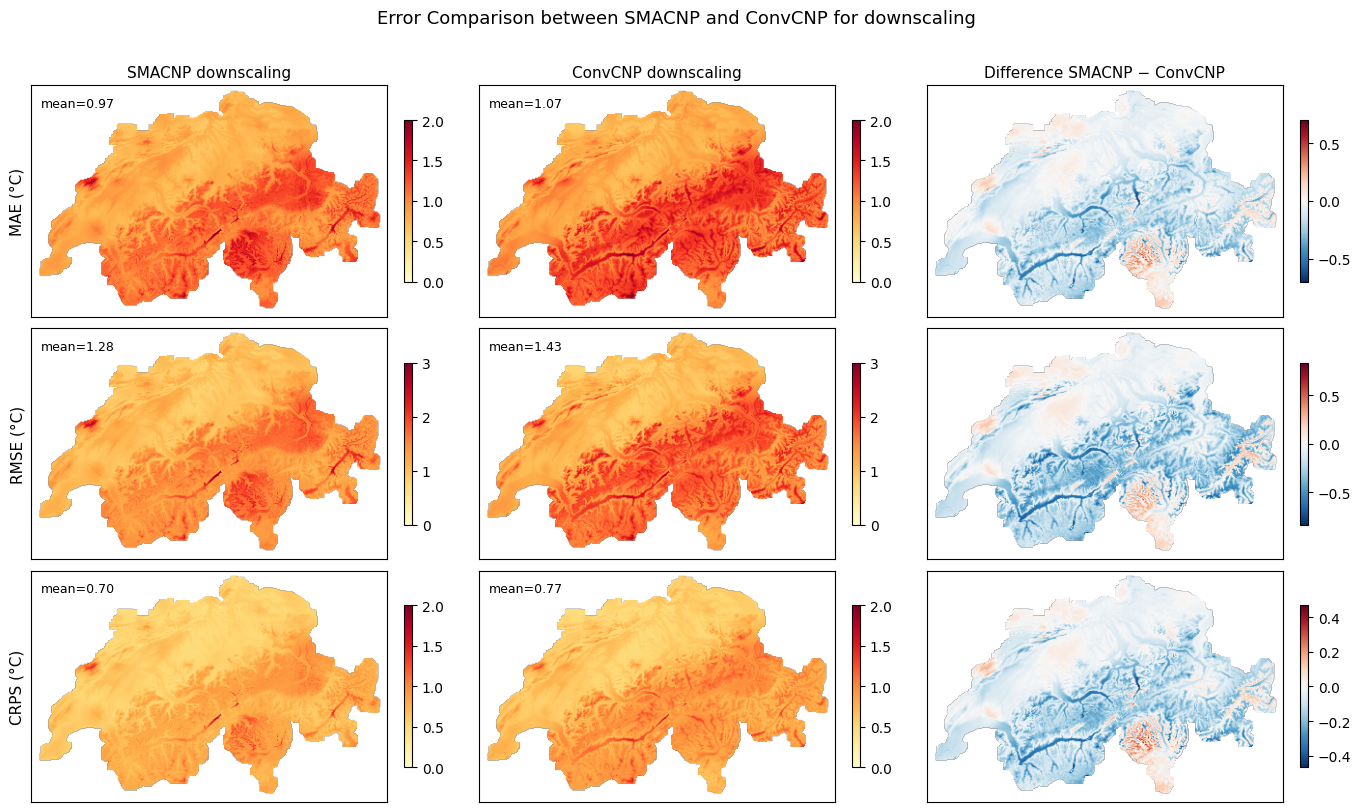

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

MODEL_A_NAME = 'final-2014-30e-5f-smacnp-mean-nll-global'  # SMACNP
MODEL_B_NAME = 'final-2014-30e-5f-6in-mean'                  # ConvCNP

MODEL_DIR = Path('./trained_models')

a = np.load(MODEL_DIR / MODEL_A_NAME / 'perpixel_grids.npz')
b = np.load(MODEL_DIR / MODEL_B_NAME / 'perpixel_grids.npz')

metrics = [
    ('mae',  'MAE (°C)',  'YlOrRd', (0, 2)),
    ('rmse', 'RMSE (°C)', 'YlOrRd', (0, 3)),
    ('crps', 'CRPS (°C)', 'YlOrRd', (0, 2)),
]

col_titles = [
    'SMACNP downscaling',
    'ConvCNP downscaling',
    'Difference SMACNP − ConvCNP',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
fig.suptitle('Error Comparison between SMACNP and ConvCNP for downscaling', fontsize=13, y=1.01)

for row, (key, label, cmap, vrange) in enumerate(metrics):
    va = a[key]
    vb = b[key]
    diff = va - vb

    diff_abs = np.nanmax(np.abs(diff))
    diff_norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-diff_abs, vmax=diff_abs)

    for col, (vals, norm, cmap_use) in enumerate([
        (va,   mcolors.Normalize(*vrange), cmap),
        (vb,   mcolors.Normalize(*vrange), cmap),
        (diff, diff_norm,                   'RdBu_r'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(vals, cmap=cmap_use, norm=norm, origin='lower', aspect='equal')
        plt.colorbar(im, ax=ax, shrink=0.7, fraction=0.035, pad=0.04)
        if row == 0:
            ax.set_title(col_titles[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=11)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        if col < 2:
            ax.text(0.03, 0.95, f'mean={np.nanmean(vals):.2f}', transform=ax.transAxes,
                    fontsize=9, va='top',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig(MODEL_DIR / 'comparison_perpixel_errors.png', dpi=150, bbox_inches='tight')
plt.show()
